PROJE BİLGİLERİ

Proje Adı:
Hybrid Heart Disease Prediction System Using
Fuzzy Three-Valued Logic and Machine Learning

Öğrenci Adı:
Amir ELAHMED

Öğrenci Numarası:
2112721307

Proje Konusu:
Bulanık Üç Değerli Mantık ve Hibrit Makine Öğrenmesi
kullanarak kalp hastalığı risk tahmini geliştirme.

# =========================================================
# PROJE AÇIKLAMASI
# =========================================================
#
# Bu projede kalp hastalığı risk tahmini için
# hibrit bir yapay zeka sistemi geliştirilmiştir.
#
# Kullanılan sistemler:
# - Fuzzy Logic
# - Machine Learning
# - Rule-Based System
# - SQLite Database
# - Streamlit Dashboard
#
# Amaç:
# Daha doğru ve gerçekçi risk tahmini yapmaktır.
#
# Veri Seti:
# Kaggle - Cardiovascular Disease Dataset
#
# Veri Boyutu:
# 70.000 satır ve 12 özellik
#
# =========================================================

In [45]:
# =========================================================
# IMPORTS
# =========================================================
#
# Bu bölümde projede kullanılacak
# Python kütüphaneleri eklenmektedir.
#
# =========================================================

import pandas as pd
import numpy as np
import sqlite3
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

import joblib

In [46]:
# =========================================================
# DATABASE
# =========================================================
#
# Bu bölümde SQLite veritabanı bağlantısı
# kurulmaktadır.
#
# =========================================================

conn = sqlite3.connect("heart.db", check_same_thread=False)

def save_table(df, table_name):
    df.to_sql(
        table_name,
        conn,
        if_exists="replace",
        index=False
    )

In [47]:
# =========================================================
# LOAD DATA
# =========================================================
#
# Bu bölümde veri seti okunmaktadır
# ve SQLite veritabanına kaydedilmektedir.
#
# =========================================================

df = pd.read_csv(
    "cardio_train.csv",
    sep=";"
)

print("Loaded:", df.shape)

save_table(df, "raw_data")


Loaded: (70000, 13)


In [48]:
# =========================================================
# PREPROCESSING
# =========================================================
#
# Bu bölümde veri temizleme işlemleri
# gerçekleştirilmektedir.
#
# =========================================================

# remove id
df.drop(columns=["id"], inplace=True)

# age -> years
df["age"] = df["age"] / 365.0

# BMI
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# remove old cols
df.drop(columns=["height", "weight"], inplace=True)

In [49]:
# =========================================================
# OUTLIERS
# =========================================================
#
# Bu bölümde mantıksız tansiyon
# değerleri veri setinden temizlenmektedir.
#
# =========================================================

df = df[
    (df["ap_hi"] > 80) &
    (df["ap_hi"] < 200)
]

df = df[
    (df["ap_lo"] > 50) &
    (df["ap_lo"] < 150)
]

print("After Cleaning:", df.shape)

save_table(df, "processed_data")

After Cleaning: (68421, 11)


In [50]:
# =========================================================
# FUZZY LOGIC
# =========================================================
#
# Bu bölümde bulanık mantık sistemi
# oluşturulmaktadır.
#
# =========================================================

def fuzzy(smoke, alco, active):

    # reverse active
    active = 1 - active

    # all healthy
    if smoke == alco == active == 0:
        return 0

    # all risky
    elif smoke == alco == active == 1:
        return 1

    # uncertain
    else:
        return 0.5

In [51]:
# =========================================================
# OTHER FACTORS
# =========================================================
#
# Bu bölümde fuzzy logic kullanılarak
# other_factors sütunu oluşturulmaktadır.
#
# =========================================================

df["other_factors"] = df.apply(
    lambda row: fuzzy(
        row["smoke"],
        row["alco"],
        row["active"]
    ),
    axis=1
)

In [52]:
# =========================================================
# COMPLETE 12 RULES
# =========================================================
#
# Bu bölümde makaledeki 12 kurala göre
# target sınıfı oluşturulmaktadır.
#
# =========================================================

def create_target(row):

    age = row["age"]
    gender = row["gender"]
    other = row["other_factors"]

    # ======================================
    # FEMALE
    # ======================================
    if gender == 1:

        # RULE 1
        if age < 55 and other == 0:
            return 0

        # RULE 2
        elif age < 55 and other == 0.5:
            return 2

        # RULE 3
        elif age < 55 and other == 1:
            return 1

        # RULE 4
        elif age >= 55 and other == 0:
            return 2

        # RULE 5
        elif age >= 55 and other == 0.5:
            return 2

        # RULE 6
        elif age >= 55 and other == 1:
            return 1

    # ======================================
    # MALE
    # ======================================
    else:

        # RULE 7
        if age < 45 and other == 0:
            return 0

        # RULE 8
        elif age < 45 and other == 0.5:
            return 2

        # RULE 9
        elif age < 45 and other == 1:
            return 1

        # RULE 10
        elif age >= 45 and other == 0:
            return 2

        # RULE 11
        elif age >= 45 and other == 0.5:
            return 2

        # RULE 12
        elif age >= 45 and other == 1:
            return 1

In [53]:
# =========================================================
# TARGET
# =========================================================
#
# Bu bölümde target sütunu
# veri setine eklenmektedir.
#
# =========================================================

df["target"] = df.apply(
    create_target,
    axis=1
)

save_table(df, "fuzzy_data")

In [54]:
# =========================================================
# CLASS DISTRIBUTION
# =========================================================
#
# Bu bölümde target sınıf dağılımı
# ekrana yazdırılmaktadır.
#
# =========================================================

print("\nTarget Distribution:")
print(df["target"].value_counts())


Target Distribution:
target
2    47137
0    21010
1      274
Name: count, dtype: int64


In [55]:
# =========================================================
# FEATURES
# =========================================================
#
# Bu bölümde feature ve target
# değişkenleri ayrılmaktadır.
#
# =========================================================

# ======================================
# NORMAL DATASET
# ======================================

X_normal = df.drop(columns=[
    "cardio",
    "target",
    "other_factors"
])

y_normal = df["cardio"]

In [56]:
# ======================================
# FUZZY DATASET
# NO LEAKAGE VERSION
# ======================================

X_fuzzy = df.drop(columns=[

    "cardio",
    "target",

    # remove fuzzy creator
    "other_factors",

    # remove original binary
    "smoke",
    "alco",
    "active"
])

y_fuzzy = df["target"]

In [57]:
# =========================================================
# SCALING
# =========================================================
#
# Bu bölümde veriler normalize edilmektedir.
#
# =========================================================

scaler_normal = StandardScaler()
scaler_fuzzy = StandardScaler()

X_normal = scaler_normal.fit_transform(X_normal)

X_fuzzy = scaler_fuzzy.fit_transform(X_fuzzy)

In [58]:
# =========================================================
# SPLIT
# =========================================================
#
# Bu bölümde veri eğitim ve test
# olarak ayrılmaktadır.
#
# =========================================================

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_normal,
    y_normal,
    test_size=0.2,
    stratify=y_normal,
    random_state=42
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fuzzy,
    y_fuzzy,
    test_size=0.2,
    stratify=y_fuzzy,
    random_state=42
)

In [59]:
# =========================================================
# SMOTE
# =========================================================
#
# Bu bölümde veri dengesizliğini azaltmak
# için SMOTE yöntemi uygulanmaktadır.
#
# =========================================================

sm = SMOTE(random_state=42)

Xf_train, yf_train = sm.fit_resample(
    Xf_train,
    yf_train
)

In [60]:
# =========================================================
# MODELS
# =========================================================
#
# Bu bölümde makine öğrenmesi
# modelleri tanımlanmaktadır.
#
# =========================================================

models = {

    "GNB": GaussianNB(),

    "LinearSVM": LinearSVC(
        max_iter=5000,
        class_weight="balanced"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100
    ),

    "DT": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=10
    ),

    "RF": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        n_jobs=-1
    ),

    "HGB": HistGradientBoostingClassifier(
        max_iter=120
    )
}

In [61]:
# =========================================================
# SPECIFICITY FUNCTION
# =========================================================
#
# Bu bölümde specificity metriğini
# hesaplayan fonksiyon oluşturulmaktadır.
#
# =========================================================

def specificity_score(cm):

    specificities = []

    for i in range(len(cm)):

        tp = cm[i, i]

        fn = cm[i, :].sum() - tp

        fp = cm[:, i].sum() - tp

        tn = cm.sum() - (tp + fn + fp)

        spec = tn / (tn + fp + 1e-10)

        specificities.append(spec)

    return np.mean(specificities)

In [62]:
# =========================================================
# TRAIN + EVALUATE
# =========================================================
#
# Bu bölümde modeller eğitilmekte
# ve performans sonuçları hesaplanmaktadır.
#
# =========================================================

results = []

best_model = None
best_name = ""
best_acc = 0

print("\n===== FINAL RESULTS =====\n")

for name, model in models.items():

    # ======================================
    # NORMAL
    # ======================================
    t0 = time.time()

    model.fit(Xn_train, yn_train)

    pred_n = model.predict(Xn_test)

    time_n = time.time() - t0

    acc_n = accuracy_score(
        yn_test,
        pred_n
    )

    prec_n = precision_score(
        yn_test,
        pred_n,
        average="macro",
        zero_division=0
    )

    rec_n = recall_score(
        yn_test,
        pred_n,
        average="macro",
        zero_division=0
    )

    f1_n = f1_score(
        yn_test,
        pred_n,
        average="macro",
        zero_division=0
    )

    cm_n = confusion_matrix(
        yn_test,
        pred_n
    )

    spec_n = specificity_score(cm_n)

    # ======================================
    # FUZZY
    # ======================================
    t0 = time.time()

    model.fit(Xf_train, yf_train)

    pred_f = model.predict(Xf_test)

    time_f = time.time() - t0

    acc_f = accuracy_score(
        yf_test,
        pred_f
    )

    prec_f = precision_score(
        yf_test,
        pred_f,
        average="macro",
        zero_division=0
    )

    rec_f = recall_score(
        yf_test,
        pred_f,
        average="macro",
        zero_division=0
    )

    f1_f = f1_score(
        yf_test,
        pred_f,
        average="macro",
        zero_division=0
    )

    cm_f = confusion_matrix(
        yf_test,
        pred_f
    )

    spec_f = specificity_score(cm_f)

    # ======================================
    # BEST MODEL
    # ======================================
    if acc_f > best_acc:

        best_acc = acc_f
        best_model = model
        best_name = name

    # ======================================
    # SAVE RESULTS
    # ======================================
    results.append([

        name,

        acc_n,
        acc_f,

        prec_n,
        prec_f,

        rec_n,
        rec_f,

        f1_n,
        f1_f,

        spec_n,
        spec_f,

        time_n,
        time_f
    ])

    print(
        f"{name:10} | "
        f"AccF:{acc_f:.3f} | "
        f"PrecF:{prec_f:.3f} | "
        f"RecallF:{rec_f:.3f} | "
        f"F1F:{f1_f:.3f} | "
        f"SpecF:{spec_f:.3f}"
    )


===== FINAL RESULTS =====

GNB        | AccF:0.549 | PrecF:0.535 | RecallF:0.690 | F1F:0.450 | SpecF:0.810
LinearSVM  | AccF:0.609 | PrecF:0.590 | RecallF:0.730 | F1F:0.498 | SpecF:0.855
AdaBoost   | AccF:0.718 | PrecF:0.592 | RecallF:0.711 | F1F:0.543 | SpecF:0.892
DT         | AccF:0.755 | PrecF:0.584 | RecallF:0.656 | F1F:0.552 | SpecF:0.900
KNN        | AccF:0.809 | PrecF:0.574 | RecallF:0.638 | F1F:0.565 | SpecF:0.913
RF         | AccF:0.853 | PrecF:0.570 | RecallF:0.583 | F1F:0.572 | SpecF:0.920
HGB        | AccF:0.838 | PrecF:0.583 | RecallF:0.633 | F1F:0.580 | SpecF:0.928


In [63]:
# =========================================================
# RESULTS DATAFRAME
# =========================================================
#
# Bu bölümde model sonuçları
# dataframe içerisine aktarılmaktadır.
#
# =========================================================

results_df = pd.DataFrame(results, columns=[

    "Model",

    "Acc_Normal",
    "Acc_Fuzzy",

    "Prec_Normal",
    "Prec_Fuzzy",

    "Recall_Normal",
    "Recall_Fuzzy",

    "F1_Normal",
    "F1_Fuzzy",

    "Spec_Normal",
    "Spec_Fuzzy",

    "Time_Normal",
    "Time_Fuzzy"
])

print("\nResults Table:")
print(results_df)

save_table(results_df, "results")


Results Table:
       Model  Acc_Normal  Acc_Fuzzy  Prec_Normal  Prec_Fuzzy  Recall_Normal  \
0        GNB    0.708513   0.549434     0.717693    0.535193       0.707333   
1  LinearSVM    0.726197   0.608842     0.729315    0.590013       0.725511   
2   AdaBoost    0.724954   0.718085     0.730642    0.591736       0.724047   
3         DT    0.723201   0.754768     0.724231    0.583510       0.722780   
4        KNN    0.709682   0.808769     0.712404    0.573995       0.709007   
5         RF    0.701644   0.853489     0.701674    0.570061       0.701492   
6        HGB    0.735111   0.837559     0.736785    0.583275       0.734607   

   Recall_Fuzzy  F1_Normal  F1_Fuzzy  Spec_Normal  Spec_Fuzzy  Time_Normal  \
0      0.689690   0.704625  0.449944     0.707333    0.810139     0.027734   
1      0.729822   0.724843  0.497782     0.725511    0.855432     0.066514   
2      0.711167   0.722696  0.542859     0.724047    0.892391     4.026108   
3      0.655863   0.722611  0.552275   

In [64]:
# =========================================================
# SAVE MODEL
# =========================================================
#
# Bu bölümde en başarılı model,
# scaler ve model adı kaydedilmektedir.
#
# =========================================================

joblib.dump(best_model, "model.pkl")

joblib.dump(scaler_fuzzy, "scaler.pkl")

joblib.dump(best_name, "model_name.pkl")

print("\nModel Saved ✅")


Model Saved ✅


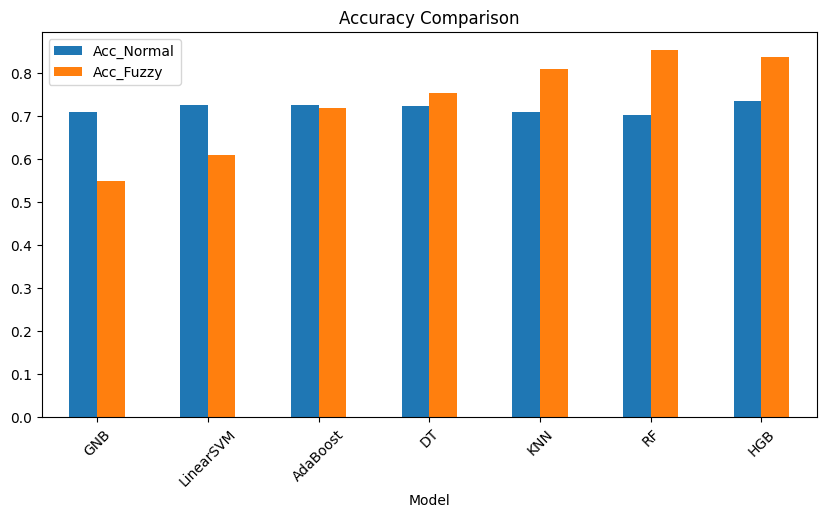

In [65]:
# =========================================================
# ACCURACY GRAPH
# =========================================================
#
# Bu bölümde accuracy sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["Acc_Normal", "Acc_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

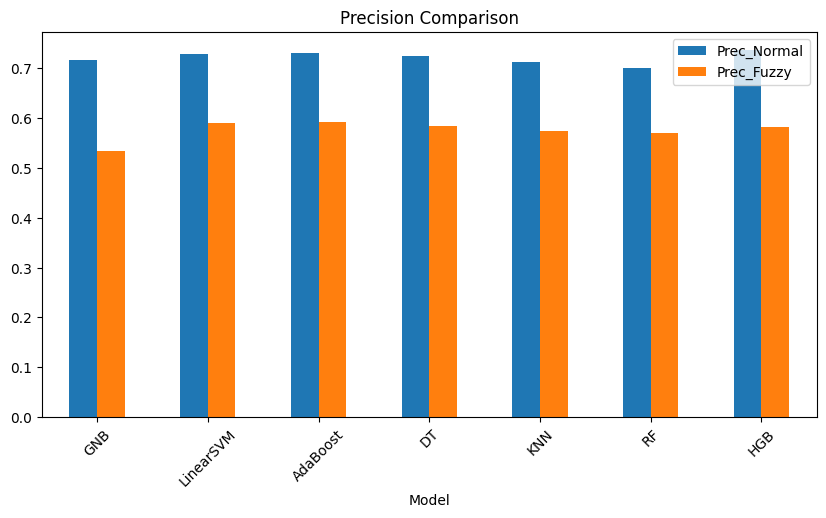

In [66]:
# =========================================================
# PRECISION GRAPH
# =========================================================
#
# Bu bölümde precision sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["Prec_Normal", "Prec_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Precision Comparison")

plt.xticks(rotation=45)

plt.show()

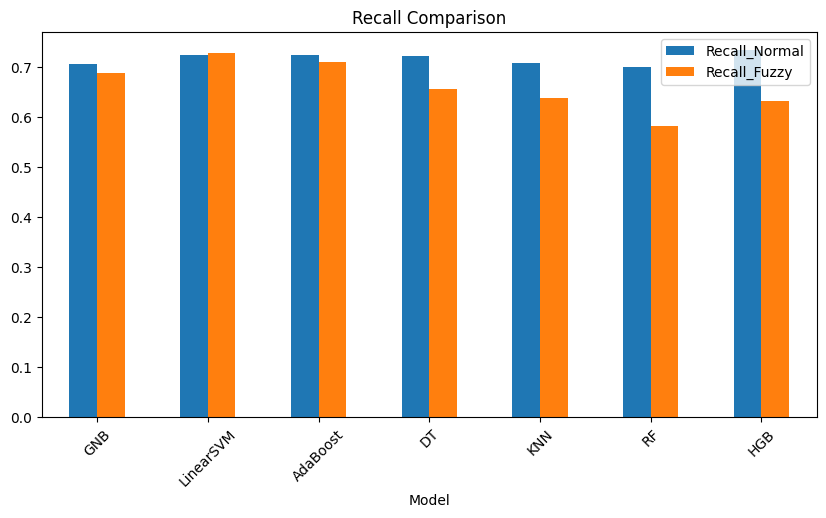

In [67]:
# =========================================================
# PRECISION GRAPH
# =========================================================
#
# Bu bölümde precision sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["Recall_Normal", "Recall_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Recall Comparison")

plt.xticks(rotation=45)

plt.show()


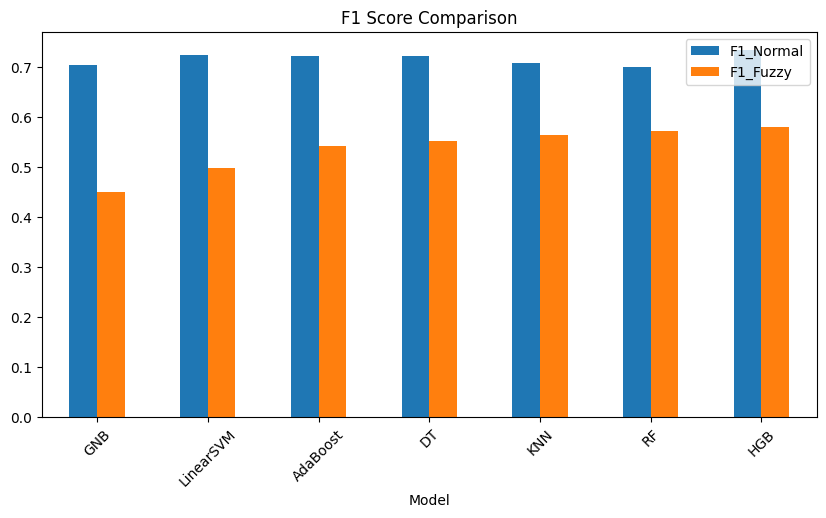

In [68]:
# =========================================================
# F1 SCORE GRAPH
# =========================================================
#
# Bu bölümde F1 Score sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["F1_Normal", "F1_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=45)

plt.show()

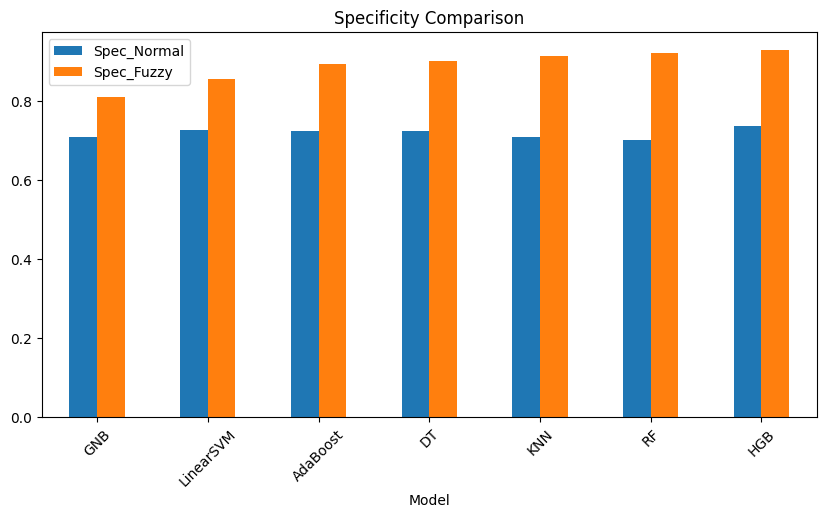

In [69]:
# =========================================================
# SPECIFICITY GRAPH
# =========================================================
#
# Bu bölümde specificity sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["Spec_Normal", "Spec_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Specificity Comparison")

plt.xticks(rotation=45)

plt.show()

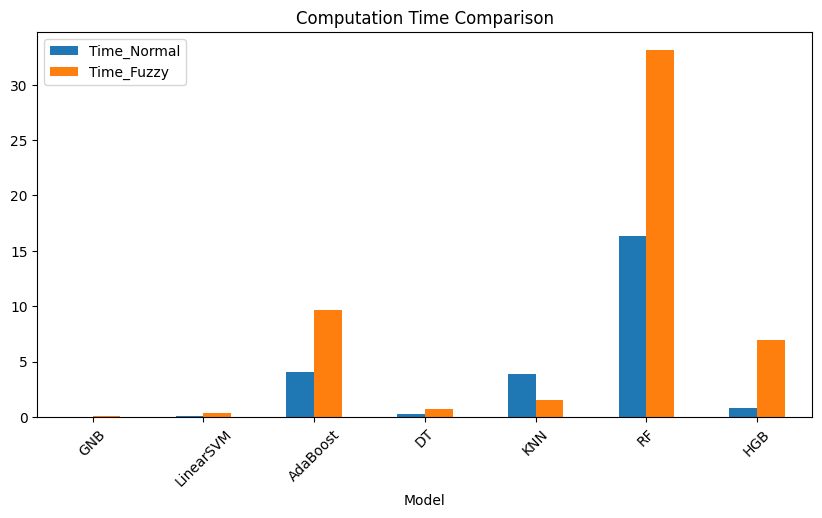

In [70]:
# =========================================================
# COMPUTATION TIME GRAPH
# =========================================================
#
# Bu bölümde computation time sonuçları
# grafik olarak gösterilmektedir.
#
# =========================================================

results_df.plot(
    x="Model",
    y=["Time_Normal", "Time_Fuzzy"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Computation Time Comparison")

plt.xticks(rotation=45)

plt.show()



Best Model: RF
Best Accuracy: 0.853


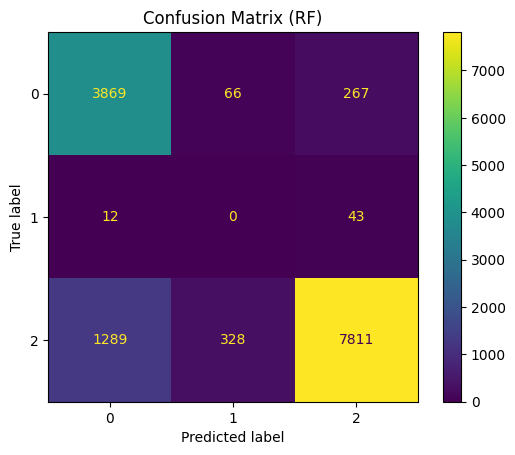

In [71]:
# =========================================================
# CONFUSION MATRIX
# =========================================================
#
# Bu bölümde en başarılı model için
# confusion matrix oluşturulmaktadır.
#
# =========================================================

print("\nBest Model:", best_name)

print("Best Accuracy:", round(best_acc, 3))

pred_best = best_model.predict(Xf_test)

cm = confusion_matrix(
    yf_test,
    pred_best
)

ConfusionMatrixDisplay(cm).plot()

plt.title(f"Confusion Matrix ({best_name})")

plt.show()

In [72]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================
#
# Bu bölümde classification report
# ekrana yazdırılmaktadır.
#
# =========================================================

print("\nClassification Report:\n")

print(classification_report(
    yf_test,
    pred_best,
    zero_division=0
))


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.92      0.83      4202
           1       0.00      0.00      0.00        55
           2       0.96      0.83      0.89      9428

    accuracy                           0.85     13685
   macro avg       0.57      0.58      0.57     13685
weighted avg       0.89      0.85      0.87     13685




Feature Importance:
       Feature  Importance
0          age    0.380838
1       gender    0.235550
6          bmi    0.161948
2        ap_hi    0.110406
3        ap_lo    0.063925
4  cholesterol    0.026423
5         gluc    0.020910


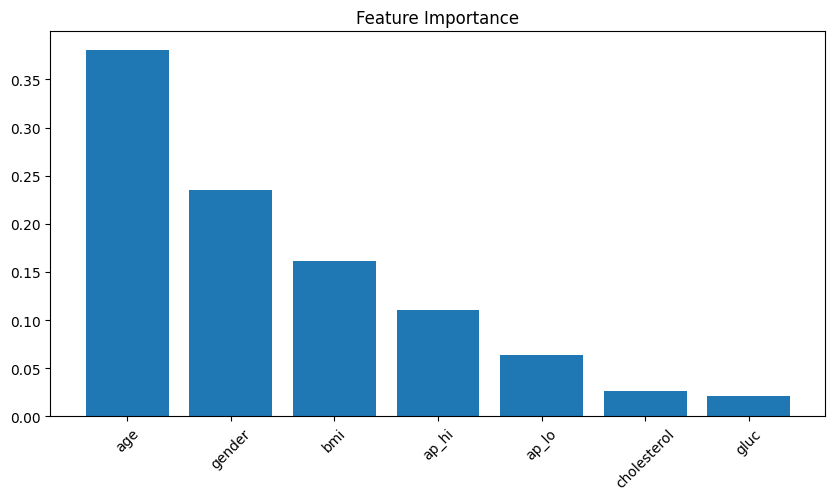


SYSTEM FINISHED SUCCESSFULLY ✅


In [73]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================
#
# Bu bölümde feature importance
# değerleri gösterilmektedir.
#
# =========================================================

if best_name == "RF":

    importance = best_model.feature_importances_

    feature_names = df.drop(columns=[

        "cardio",
        "target",

        "other_factors",

        "smoke",
        "alco",
        "active"

    ]).columns

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    imp_df = imp_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance:")
    print(imp_df)

    plt.figure(figsize=(10, 5))

    plt.bar(
        imp_df["Feature"],
        imp_df["Importance"]
    )

    plt.xticks(rotation=45)

    plt.title("Feature Importance")

    plt.show()
    print("\nSYSTEM FINISHED SUCCESSFULLY ✅")

In [74]:
# =========================================================
# MODEL KAYDETME
# =========================================================
#
# Bu bölümde en başarılı model,
# scaler ve model adı dosya olarak
# kaydedilmektedir.
#
# =========================================================


import joblib

joblib.dump(best_model, "model.pkl")

joblib.dump(scaler_fuzzy, "scaler.pkl")

joblib.dump(best_name, "model_name.pkl")

print("Model Saved ✅")

Model Saved ✅
